# Creador del modelo elegido de imagen

## Configuración de entorno

In [ ]:
# Descomenta si necesitas instalar
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install transformers albumentations h5py pandas numpy matplotlib scikit-learn

In [3]:
# 1.2 IMPORTACIONES
# ------------------------------------------------------------------------------
import os
import gc
import sys
import random
import time
import warnings
from pathlib import Path

# Manipulación de Datos
import numpy as np
import pandas as pd
import h5py
import cv2  # OpenCV para lectura rápida de imágenes

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler # Para Mixed Precision Training

# Hugging Face & Aumentación
import transformers
from transformers import AutoModelForImageClassification, AutoConfig
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Configuración Visual
sns.set_style("whitegrid")
warnings.filterwarnings('ignore') # Ignorar warnings no críticos de HF

print(f"✅ PyTorch Version: {torch.__version__}")
print(f"✅ Transformers Version: {transformers.__version__}")

✅ PyTorch Version: 2.5.1+cu121
✅ Transformers Version: 4.57.3


In [ ]:
# 1.3 REPRODUCIBILIDAD (CRÍTICO PARA ENSEMBLE)
# ------------------------------------------------------------------------------
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False # True acelera pero reduce determinismo
    print(f"🔒 Semillas fijadas en: {seed}")

seed_everything(SEED)

🔒 Semillas fijadas en: 42


In [5]:
# 1.4 HIPERPARÁMETROS Y HARDWARE
# ------------------------------------------------------------------------------

# Configuración del Modelo
MODEL_NAME = "Aayan1122/skin-cancer-efficientnetb3"
IMG_SIZE = 300       # Resolución nativa óptima para EfficientNet-B3
NUM_CLASSES = 1      # Binary Classification

# Entrenamiento
BATCH_SIZE = 32      # Ajustar según tu VRAM (B3 es pesado). Si da OOM, bajar a 16.
EPOCHS = 10          # 10 épocas suelen bastar con Transfer Learning
LEARNING_RATE = 1e-4 # LR conservador para no destruir los pesos pre-entrenados
WEIGHT_DECAY = 1e-5  # Regularización L2

# Hardware
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚙️ Dispositivo de entrenamiento: {DEVICE}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM Total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    
# Mixed Precision Scaler
# Esto gestiona dinámicamente el escalado de gradientes para evitar underflow en float16
scaler = GradScaler()

⚙️ Dispositivo de entrenamiento: cuda
   GPU: NVIDIA GeForce RTX 4060 Laptop GPU
   VRAM Total: 8.18 GB


In [6]:
# 1.5 RUTAS DE DATOS
# ------------------------------------------------------------------------------

# Directorio actual y padre
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
data_dir = os.path.join(parent_dir, 'data')

# Archivos
TRAIN_CSV = os.path.join(data_dir, 'new-train-metadata.csv')
TRAIN_HDF5 = os.path.join(data_dir, 'train-image.hdf5')
TEST_CSV  = os.path.join(data_dir, 'students-test-metadata.csv')
TEST_HDF5  = os.path.join(data_dir, 'test-image.hdf5')

# Verificación rápida
required_files = [TRAIN_CSV, TRAIN_HDF5, TEST_CSV, TEST_HDF5]
missing_files = [f for f in required_files if not os.path.exists(f)]

if not missing_files:
    print(f"✅ Todos los archivos de datos encontrados en: {data_dir}")
else:
    print(f"❌ FALTAN ARCHIVOS: {missing_files}")
    raise FileNotFoundError("Revisa la estructura de carpetas.")

✅ Todos los archivos de datos encontrados en: /home/jorge/Documentos/Deep/ISIC_DL/data


## Gestion de datos (HDF5 y CSV)

In [7]:
# 2.1 PREPARACIÓN DE METADATOS Y SPLIT
# ------------------------------------------------------------------------------
from sklearn.model_selection import train_test_split

# 1. Cargar CSVs
df_train_full = pd.read_csv(TRAIN_CSV)
df_test = pd.read_csv(TEST_CSV)

# 2. Selección de Columnas
# Solo necesitamos el ID para buscar la imagen y el Target para entrenar
df_train = df_train_full[['isic_id', 'target']].copy()

# 3. Split Estratificado (Idéntico al notebook de metadatos)
# Esto garantiza que X_val contenga las mismas imágenes que X_val del modelo tabular
X_train, X_val, y_train, y_val = train_test_split(
    df_train, 
    df_train['target'], 
    test_size=0.2, 
    stratify=df_train['target'], 
    random_state=SEED
)

print(f"📊 Dimensiones del Dataset:")
print(f"   Train: {len(X_train)} imágenes | Positivos: {y_train.sum()} ({y_train.mean():.4%})")
print(f"   Val:   {len(X_val)} imágenes  | Positivos: {y_val.sum()} ({y_val.mean():.4%})")
print(f"   Test:  {len(df_test)} imágenes   (Sin etiquetas)")

📊 Dimensiones del Dataset:
   Train: 320767 imágenes | Positivos: 274 (0.0854%)
   Val:   80192 imágenes  | Positivos: 69 (0.0860%)
   Test:  100 imágenes   (Sin etiquetas)


In [8]:
# 2.2 DEFINICIÓN DE TRANSFORMACIONES (ALBUMENTATIONS)
# ------------------------------------------------------------------------------

# Estadísticas de ImageNet (Estándar para Transfer Learning)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_transforms(data='train'):
    if data == 'train':
        return A.Compose([
            # 1. Transformaciones Geométricas
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=60, p=0.7),
            
            # 2. Transformaciones de Color/Iluminación (Robustez TBP)
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6),
            A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.5),
            
            # 3. Regularización (Cutout / CoarseDropout)
            # Obliga a la red a no fijarse solo en un punto.
            A.CoarseDropout(max_holes=8, max_height=16, max_width=16, fill_value=0, p=0.3),
            
            # 4. Normalización y Conversión a Tensor
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2()
        ])
    
    elif data == 'valid':
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2()
        ])

In [9]:
# 2.3 CLASE DATASET ROBUSTA PARA HDF5
# ------------------------------------------------------------------------------

class ISICHDF5Dataset(Dataset):
    def __init__(self, df, hdf5_path, transform=None):
        self.df = df.reset_index(drop=True)
        self.hdf5_path = hdf5_path
        self.transform = transform
        self.fp = None # Puntero al archivo (File Pointer) inicializado en None
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # 1. Lazy Loading: Abrir archivo solo si no está abierto en este worker
        if self.fp is None:
            self.fp = h5py.File(self.hdf5_path, 'r')
            
        row = self.df.iloc[idx]
        isic_id = row['isic_id']
        
        # 2. Leer bytes de imagen
        try:
            image_data = self.fp[isic_id][()] # Leer dataset HDF5
        except KeyError:
            # Fallback por si acaso el ID no existe (no debería pasar)
            print(f"⚠️ Missing ID: {isic_id}")
            return torch.zeros((3, IMG_SIZE, IMG_SIZE)), torch.tensor(0.0)

        # 3. Decodificar (Bytes -> Numpy BGR -> Numpy RGB)
        nparr = np.frombuffer(image_data, np.uint8)
        image = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # 4. Aplicar Augmentations
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
            
        # 5. Retornar Target si existe (Train/Val), sino solo imagen (Test)
        if 'target' in row:
            return image, torch.tensor(row['target'], dtype=torch.float32)
        else:
            return image

In [10]:
# 2.4 SAMPLER PARA DESBALANCEO (OVERSAMPLING)
# ------------------------------------------------------------------------------

# Calculamos pesos para el sampler
# Objetivo: Que la probabilidad de sacar un ejemplo sea inversa a su frecuencia
class_counts = y_train.value_counts().sort_index() # 0: N_benign, 1: N_malig
class_weights = 1.0 / class_counts
sample_weights = y_train.map(class_weights).values

# Convertir a tensor
sampler_weights = torch.from_numpy(sample_weights).double()

# Crear Sampler
# num_samples=len(X_train) asegura que una época tenga el mismo tamaño que el dataset original,
# pero con la proporción de clases balanceada artificialmente.
sampler = WeightedRandomSampler(
    weights=sampler_weights,
    num_samples=len(X_train),
    replacement=True
)

print("⚖️ WeightedRandomSampler configurado para balancear el entrenamiento.")

# ------------------------------------------------------------------------------
# 2.5 CREACIÓN DE DATALOADERS
# ------------------------------------------------------------------------------

# Datasets
train_dataset = ISICHDF5Dataset(X_train, TRAIN_HDF5, transform=get_transforms('train'))
val_dataset   = ISICHDF5Dataset(X_val,   TRAIN_HDF5, transform=get_transforms('valid'))
test_dataset  = ISICHDF5Dataset(df_test, TEST_HDF5,  transform=get_transforms('valid'))

# Loaders
# num_workers=4 es un buen estándar. Si da error en Windows, usar 0.
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    sampler=sampler,      # ¡Usamos el sampler aquí! (No shuffle=True)
    num_workers=4, 
    pin_memory=True       # Acelera transferencia a GPU
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)

print(f"✅ DataLoaders listos.")
print(f"   Batches por época: {len(train_loader)}")

⚖️ WeightedRandomSampler configurado para balancear el entrenamiento.
✅ DataLoaders listos.
   Batches por época: 10024


## DataSet y Transformaciones 

In [11]:
# 3.1 FUNCIÓN HELPER: DES-NORMALIZACIÓN PARA VISUALIZACIÓN
# ------------------------------------------------------------------------------

def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """
    Convierte un tensor normalizado (C, H, W) de vuelta a imagen numpy (H, W, C).
    """
    # Clonar para no modificar el tensor original en memoria
    img = tensor.clone().detach().cpu().numpy()
    
    # Transponer: (C, H, W) -> (H, W, C) para Matplotlib
    img = img.transpose(1, 2, 0)
    
    # Des-normalizar: img = (img * std) + mean
    img = (img * np.array(std)) + np.array(mean)
    
    # Clip para asegurar rango [0, 1]
    img = np.clip(img, 0, 1)
    return img

📦 Dimensiones del Batch: torch.Size([32, 3, 300, 300])
   Labels en este batch: torch.Size([32])


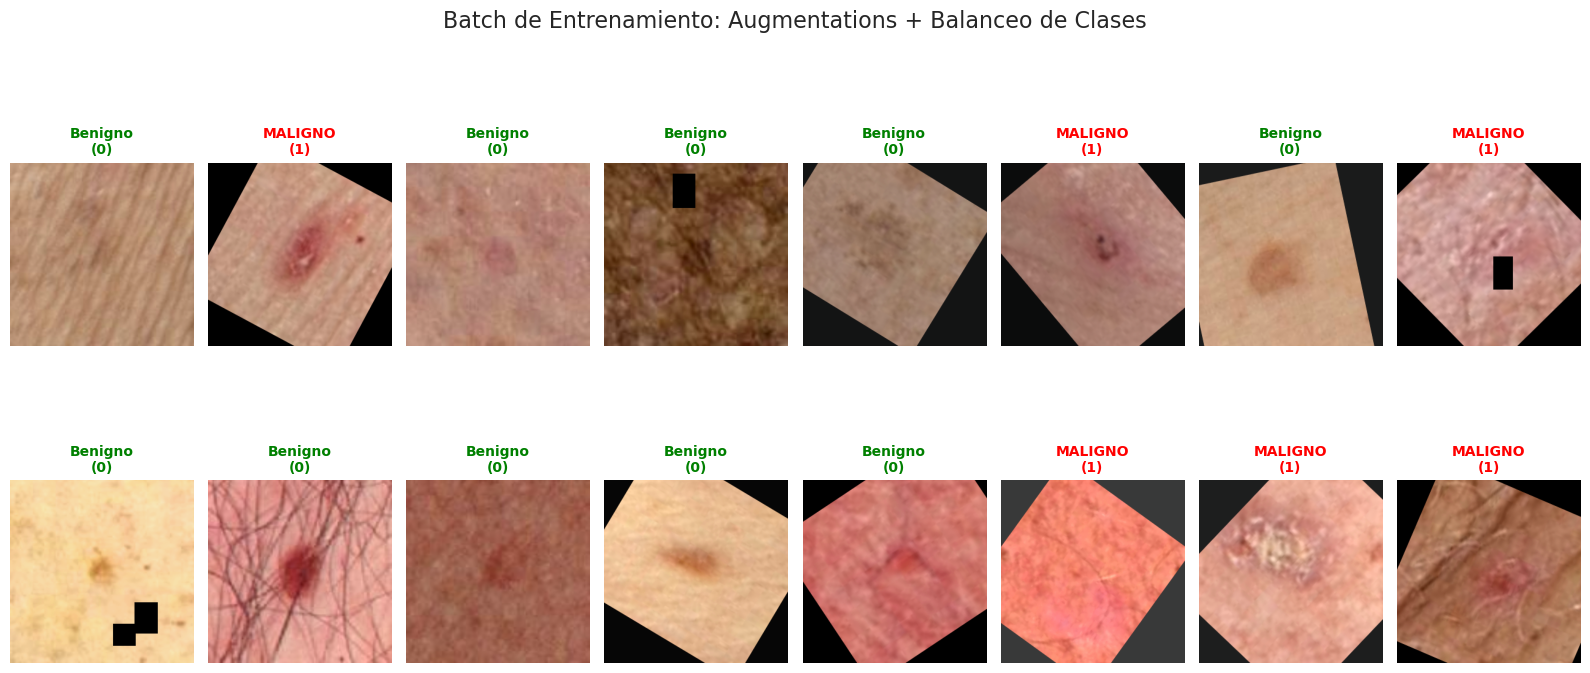


🔎 Análisis del Sampler en este Batch:
   Malignos encontrados: 16 de 32
   Porcentaje en batch:  50.00% (vs 0.08% original)
✅ ÉXITO: El WeightedRandomSampler está alimentando casos positivos al modelo.


In [12]:
# 3.2 SANITY CHECK: VISUALIZACIÓN DE AUGMENTATIONS Y SAMPLER
# ------------------------------------------------------------------------------

# Obtener un batch del DataLoader de entrenamiento
images, labels = next(iter(train_loader))

print(f"📦 Dimensiones del Batch: {images.shape}")
print(f"   Labels en este batch: {labels.shape}")

# Configurar plot
plt.figure(figsize=(16, 8))
plt.suptitle("Batch de Entrenamiento: Augmentations + Balanceo de Clases", fontsize=16)

# Mostrar hasta 16 imágenes (2 filas de 8)
for i in range(min(16, len(images))):
    plt.subplot(2, 8, i + 1)
    
    # Des-normalizar imagen
    img_show = denormalize(images[i])
    label = labels[i].item()
    
    plt.imshow(img_show)
    
    # Título condicional: Rojo si es Maligno, Verde si es Benigno
    color = 'red' if label == 1.0 else 'green'
    status = 'MALIGNO' if label == 1.0 else 'Benigno'
    
    plt.title(f"{status}\n({label:.0f})", color=color, fontweight='bold', fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Verificación numérica del balanceo en este batch
n_pos = labels.sum().item()
print(f"\n🔎 Análisis del Sampler en este Batch:")
print(f"   Malignos encontrados: {int(n_pos)} de {len(labels)}")
print(f"   Porcentaje en batch:  {n_pos/len(labels):.2%} (vs 0.08% original)")
if n_pos > 2:
    print("✅ ÉXITO: El WeightedRandomSampler está alimentando casos positivos al modelo.")
else:
    print("⚠️ ALERTA: Pocos positivos en este batch. Verifica los pesos del sampler.")

## Definición del modelo

In [14]:
# 4. DEFINICIÓN DEL MODELO CON TIMM (PyTorch Image Models)
# ------------------------------------------------------------------------------
import timm

# Asegúrate de tener timm instalado
# !pip install timm

print(f"🏗️ Construyendo modelo EfficientNet-B3 con timm...")

# Definimos el nombre del modelo en el Hub y el nombre base
HUB_MODEL = "hf_hub:Aayan1122/skin-cancer-efficientnetb3"
BASE_MODEL = "efficientnet_b3"

try:
    print(f"🔄 Intentando descargar pesos específicos: {HUB_MODEL}...")
    # num_classes=1 ajusta automáticamente la última capa (Head)
    # pretrained=True descarga los pesos
    model = timm.create_model(
        HUB_MODEL, 
        pretrained=True, 
        num_classes=1
    )
    print("✅ Pesos de Cáncer de Piel cargados exitosamente.")

except Exception as e:
    print(f"⚠️ Aviso de Seguridad/Compatibilidad: {e}")
    print(f"🔄 FALLBACK: Cargando pesos estándar de ImageNet ({BASE_MODEL}).")
    print("   Esto es seguro y muy efectivo dado que tenemos 320k imágenes para Fine-Tuning.")
    
    model = timm.create_model(
        BASE_MODEL, 
        pretrained=True, 
        num_classes=1
    )
    print("✅ Pesos de ImageNet cargados exitosamente.")

# Mover a GPU
model = model.to(DEVICE)
print(f"🚀 Modelo en: {DEVICE}")

# ------------------------------------------------------------------------------
# 4.1 CONFIGURACIÓN DE PARÁMETROS ENTRENABLES
# ------------------------------------------------------------------------------
# Full Fine-Tuning: Entrenamos todas las capas para adaptar los filtros
# de dermoscopia/imagenet a las imágenes TBP (celular).

for param in model.parameters():
    param.requires_grad = True

total_params = sum(p.numel() for p in model.parameters())
print(f"📊 Parámetros totales a entrenar: {total_params:,}")

🏗️ Construyendo modelo EfficientNet-B3 con timm...
🔄 Intentando descargar pesos específicos: hf_hub:Aayan1122/skin-cancer-efficientnetb3...
⚠️ Aviso de Seguridad/Compatibilidad: 404 Client Error. (Request ID: Root=1-6925de70-36db98e26938ef104b7e7335;431c581f-b0aa-4540-9322-9a1bac268c39)

Entry Not Found for url: https://huggingface.co/Aayan1122/skin-cancer-efficientnetb3/resolve/main/config.json.
🔄 FALLBACK: Cargando pesos estándar de ImageNet (efficientnet_b3).
   Esto es seguro y muy efectivo dado que tenemos 320k imágenes para Fine-Tuning.


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

✅ Pesos de ImageNet cargados exitosamente.
🚀 Modelo en: cuda
📊 Parámetros totales a entrenar: 10,697,769


## Configuración de entrenamiento

## Entrenamiento

## Evaluación y sanity checks

## Inferencia en test y generación de archivos